In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn

LR = 1e-3
EPOCHS = 30
BATCH_SIZE = 32
NUM_WORKERS = 2
NUM_CLASSES = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [2]:
import pickle
import numpy as np
import os

def load_batch(file_path):
    with open(file=file_path, mode='rb') as f:
        batch = pickle.load(f, encoding='bytes')
    
    data = batch[b'data']
    labels = batch[b'labels']
    return data, labels


def load_cifar10(data_dir):
    train_data = []
    train_labels = []

    for i in range(5):
        batch_path = os.path.join(data_dir, f"data_batch_{i + 1}")
        data, labels = load_batch(batch_path)
        train_data.append(data)
        train_labels.extend(labels)
    
    train_data = np.vstack(train_data)
    train_labels = np.array(train_labels)

    test_batch_path = os.path.join(data_dir, "test_batch")
    test_data, test_labels = load_batch(test_batch_path)

    return train_data, train_labels, test_data, test_labels

def reshape_images(data):
    data = data.reshape(-1, 3, 32, 32)
    data = data.astype(np.float32) / 255.0
    return data

In [3]:
data_dir = "/kaggle/input/datasets/eliomorningstar/cifar10-private/cifar-10-python/cifar-10-batches-py"
train_data, train_labels, test_data, test_labels = load_cifar10(data_dir=data_dir)

train_data = reshape_images(train_data)
test_data = reshape_images(test_data)

print(train_data.shape)
print(test_data.shape)

(50000, 3, 32, 32)
(10000, 3, 32, 32)


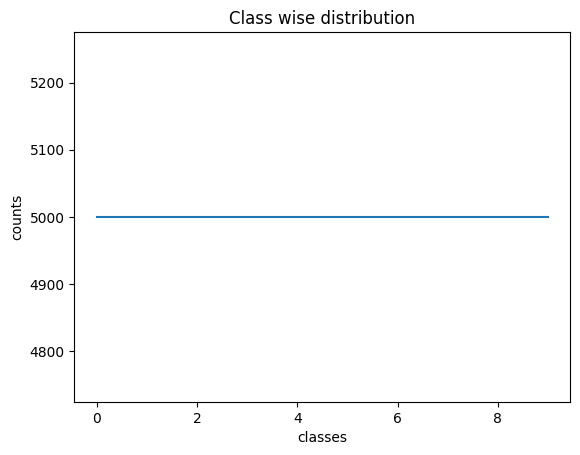

In [4]:
import matplotlib.pyplot as plt
import numpy as np

unique, counts = np.unique(train_labels, return_counts=True)

plt.plot(unique, counts)
plt.title("Class wise distribution")
plt.xlabel("classes")
plt.ylabel("counts")
plt.show()

In [5]:
unique

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

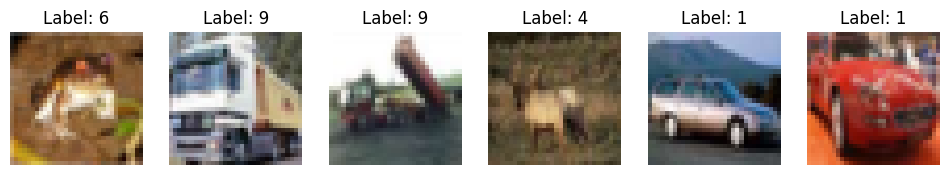

In [6]:
def show_images(x, y, num=6):
    fig, axes = plt.subplots(nrows=1, ncols=num, figsize=(12, 3))
    for i in range(num):
        img = x[i].transpose(1, 2, 0)
        axes[i].imshow(img)
        axes[i].set_title(f"Label: {y[i]}")
        axes[i].axis("off")
    
    plt.show()
show_images(train_data, train_labels)

In [7]:
mean = train_data.mean(axis=(0, 2, 3))
std = train_data.std(axis=(0, 2, 3))

print(f"Mean: {mean}")
print(f"Std: {std}")

Mean: [0.4914009  0.48215896 0.4465308 ]
Std: [0.24703279 0.24348423 0.26158753]


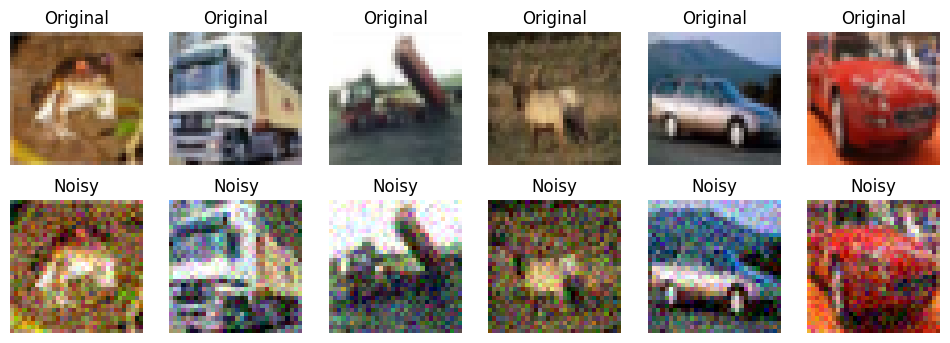

In [8]:
def show_noisy(x):
    noisy = x + 0.1*np.random.randn(*x.shape)
    noisy = np.clip(noisy, 0, 1)
    
    fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(12, 4))
    
    for i in range(6):
        axes[0, i].imshow(x[i].transpose(1, 2, 0))
        axes[0, i].set_title("Original")
        
        axes[1, i].imshow(noisy[i].transpose(1, 2, 0))
        axes[1, i].set_title("Noisy")
        
        axes[0, i].axis("off")
        axes[1, i].axis("off")
    
    plt.show()
show_noisy(train_data)

In [9]:
class Cifar10Dataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        x = self.data[index]
        y = self.labels[index]
        return x, y

In [10]:
class DenoisingCifar10(Dataset):
    def __init__(self, data, noise_factor=0.1):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.noise_factor = noise_factor
    
    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        clean = self.data[index]
        noise = self.noise_factor * torch.randn_like(clean)
        noisy = torch.clamp(clean + noise, 0, 1)
        return noisy, clean

In [11]:
trainDataset = DenoisingCifar10(data=train_data, noise_factor=0.1)
testDataset = DenoisingCifar10(data=test_data, noise_factor=0.1)

trainloader = DataLoader(
    dataset = trainDataset,
    batch_size = BATCH_SIZE,
    num_workers=0,
    shuffle=True
)

testloader = DataLoader(
    dataset = testDataset,
    batch_size = BATCH_SIZE,
    num_workers=0,
    shuffle=False
)

In [12]:
class ConvDAE(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),  # 32x16x1
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 64x8x8
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), # 128x4x4
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), # 64x8x8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  # 32x16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),   # 3x32x32
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [17]:
model = ConvDAE()
model = model.to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.L1Loss()

In [18]:
import torch

def psnr(pred, target):
    mse = torch.mean((pred - target) ** 2)
    return 20 * torch.log10(1.0 / torch.sqrt(mse))

In [19]:

train_losses = []
test_accuracies = []
for epoch in range(EPOCHS):
    runningloss = 0
    model.train()
    for noisy, clean in trainloader:
        noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)

        outputs = model(noisy)
        outputs = outputs.view(noisy.size(0), 3, 32, 32)

        loss = criterion(outputs, clean)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        runningloss += loss.item()
    runningloss = runningloss / len(trainloader)
    train_losses.append(runningloss)
    
    test_psnr = 0
    model.eval()
    for noisy, clean in testloader:
        noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)

        outputs = model(noisy)
        outputs = outputs.view(noisy.size(0), 3, 32, 32)

        loss = psnr(outputs, clean)
        test_psnr += loss.item()
    test_psnr = test_psnr / len(testloader)
    test_accuracies.append(test_psnr)
           
    print(f"[{epoch + 1}] train loss: {runningloss:.4f} test loss: {test_psnr}")

[1] train loss: 0.0687 test loss: 22.988409572516005
[2] train loss: 0.0468 test loss: 24.441679561480928
[3] train loss: 0.0427 test loss: 24.855961217666966
[4] train loss: 0.0405 test loss: 25.39017941776556
[5] train loss: 0.0392 test loss: 25.768527649462033
[6] train loss: 0.0382 test loss: 25.832265969663382
[7] train loss: 0.0376 test loss: 26.105210910589932
[8] train loss: 0.0370 test loss: 26.256092193408517
[9] train loss: 0.0365 test loss: 26.35076549639717
[10] train loss: 0.0360 test loss: 26.41734585137413
[11] train loss: 0.0357 test loss: 26.37417784742654
[12] train loss: 0.0354 test loss: 26.33495481935934
[13] train loss: 0.0352 test loss: 26.720355883954813
[14] train loss: 0.0349 test loss: 26.651528666194636
[15] train loss: 0.0348 test loss: 26.718016700622755
[16] train loss: 0.0346 test loss: 26.702125506660046
[17] train loss: 0.0344 test loss: 26.80184043786777
[18] train loss: 0.0342 test loss: 26.90607633986793
[19] train loss: 0.0341 test loss: 26.781912

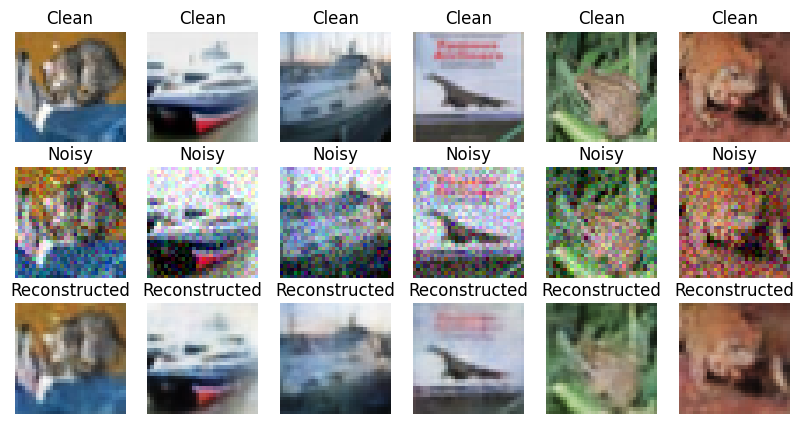

In [20]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    noisy, clean = next(iter(testloader))
    noisy, clean = noisy.to(DEVICE), clean.to(DEVICE)

    recon = model(noisy)

noisy = noisy.to("cpu")
clean = clean.to("cpu")
recon = recon.to("cpu")
recon = recon.view(recon.size(0), 3, 32, 32)

fig, axes = plt.subplots(nrows = 3, ncols = 6, figsize=(10, 5))
for i in range(6):
    axes[0, i].imshow(clean[i].permute(1, 2, 0))
    axes[0, i].set_title("Clean")

    axes[1, i].imshow(noisy[i].permute(1, 2, 0))
    axes[1, i].set_title("Noisy")

    axes[2, i].imshow(recon[i].permute(1, 2, 0))
    axes[2, i].set_title("Reconstructed")

    for ax in axes[:, i]:
        ax.axis("off")
plt.show()